Dataset Shape: (44898, 5)

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


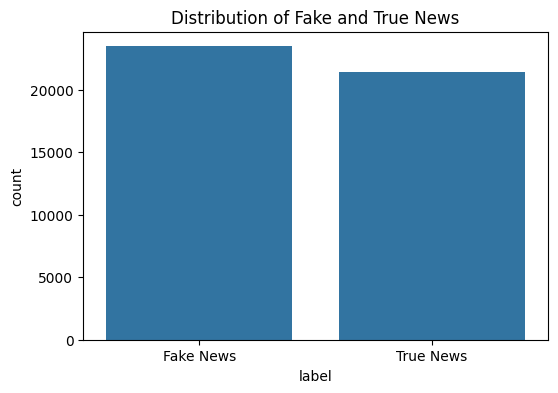

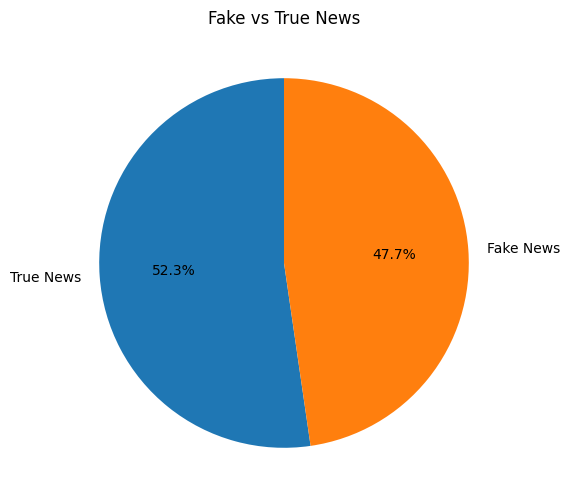

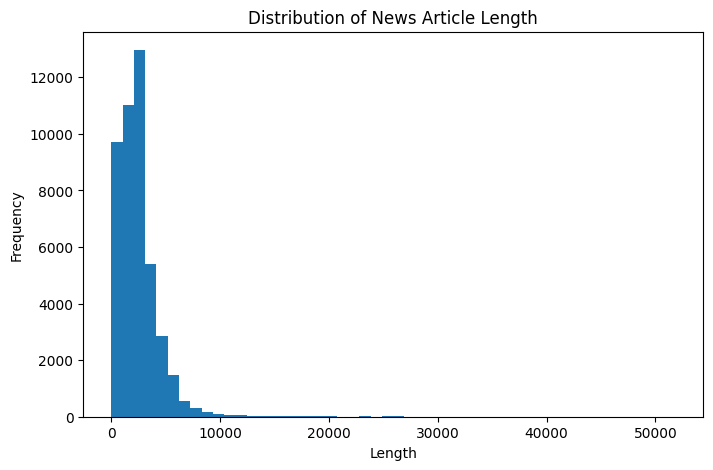


Accuracy: 0.982739420935412

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



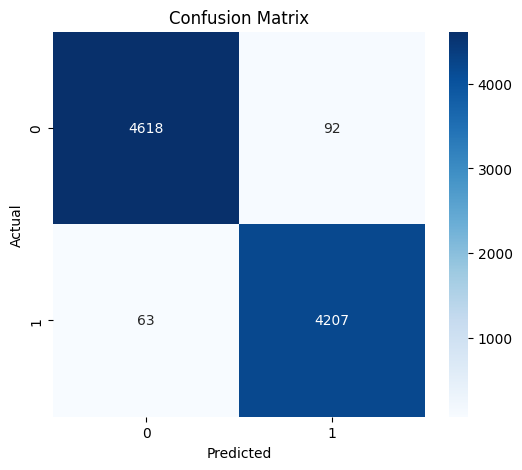


Enter a news article:
NASA Confirms humans landed on Jupiter yesterday

Prediction: Fake News


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset Shape:", data.shape)
print("\nMissing Values:")
print(data.isnull().sum())

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=data)
plt.xticks([0,1], ['Fake News', 'True News'])
plt.title("Distribution of Fake and True News")
plt.show()


counts = data['label'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts,
        labels=['True News', 'Fake News'],
        autopct='%1.1f%%',
        startangle=90)
plt.title("Fake vs True News")
plt.show()

data["text_length"] = data["text"].apply(len)

plt.figure(figsize=(8,5))
plt.hist(data["text_length"], bins=50)
plt.title("Distribution of News Article Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)


accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


news = input("\nEnter a news article:\n")

news_vector = vectorizer.transform([news])

prediction = model.predict(news_vector)

if prediction[0] == 0:
    print("\nPrediction: Fake News")
else:
    print("\nPrediction: True News")